<center><h1>Sentiment Analysis on Womens Clothing Reviews using Pretrained BERT</h1></center>

## Overview
This notebook applies a **pretrained BERT model** (`bert-base-uncased`) to perform
**sentiment analysis** on the **Womens Clothing E-Commerce Reviews** dataset.

Each customer review (text feedback) is analysed to determine the buyers sentiment:
- **0 - Negative** - The customer is unhappy / dissatisfied
- **1 - Neutral**  - The customer has mixed feelings
- **2 - Positive** - The customer is happy / satisfied

The sentiment label is derived from the `Rating` column:
- 1-2 stars -> Negative
- 3 stars   -> Neutral
- 4-5 stars -> Positive


### Pipeline
1. Load and explore the dataset
2. Preprocess text and derive sentiment labels
3. Train / Test split
4. Tokenize with BertTokenizerFast
5. Build a BERT-based classification model
6. Train the model
7. Evaluate on test data -> **Classification Report**


## Step 1 - Install and Import Dependencies

In [3]:
import os
import numpy as np
import pandas as pd
import re
import time
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
print(f"TensorFlow version: {tf.__version__}")

# Correct import for newer versions
from transformers import AutoTokenizer, TFAutoModel
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from sklearn.utils.class_weight import compute_class_weight

import matplotlib.pyplot as plt
import urllib.request

# Set seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

TensorFlow version: 2.20.0


## Step 2 - Load the Dataset

We use the real **Womens Clothing E-Commerce Reviews** dataset (23,486 reviews)
which contains genuine customer reviews and ratings for womens clothing items
sold online - this is our stand-in "product feedback" data (فيدباك المشترين الحقيقي).

The cell below **downloads the CSV automatically** the first time it runs, so
the notebook works end-to-end with no manual upload step.

**Key columns:**
- `Review Text` - the customers written feedback (our input X)
- `Rating` - 1 to 5 stars (used to derive the sentiment label y)

**Label mapping (Rating -> Sentiment):**

| Rating | Sentiment | Meaning |
|--------|-----------|-----------------------------------|
| 1, 2   | 0         | Negative (عميل غير راضي)  |
| 3      | 1         | Neutral  (مشاعر مختلطة)   |
| 4, 5   | 2         | Positive (عميل سعيد/راضي) |


In [4]:
import os
import urllib.request

CSV_PATH = "Womens Clothing E-Commerce Reviews.csv"
CSV_URL  = (
    "https://raw.githubusercontent.com/nethajinirmal13/Training-datasets/"
    "main/Womens%20Clothing%20E-Commerce%20Reviews.csv"
)

if not os.path.exists(CSV_PATH):
    print("Downloading dataset...")
    urllib.request.urlretrieve(CSV_URL, CSV_PATH)
    print("Downloaded:", CSV_PATH)
else:
    print("Dataset already present:", CSV_PATH)

df = pd.read_csv(CSV_PATH, index_col=0)
df.head()

Downloaded: Womens Clothing E-Commerce Reviews.csv


,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [5]:
print("Dataset shape:", df.shape)
df.info()

Dataset shape: (23486, 10)
<class 'pandas.core.frame.DataFrame'>
Index: 23486 entries, 0 to 23485
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Clothing ID              23486 non-null  int64 
 1   Age                      23486 non-null  int64 
 2   Title                    19676 non-null  object
 3   Review Text              22641 non-null  object
 4   Rating                   23486 non-null  int64 
 5   Recommended IND          23486 non-null  int64 
 6   Positive Feedback Count  23486 non-null  int64 
 7   Division Name            23472 non-null  object
 8   Department Name          23472 non-null  object
 9   Class Name               23472 non-null  object
dtypes: int64(5), object(5)
memory usage: 2.0+ MB


In [6]:
df["Rating"].value_counts().sort_index()

Rating
1      842
2     1565
3     2871
4     5077
5    13131
Name: count, dtype: int64

## Step 3 - Derive Sentiment Labels and Preprocess Text

In [7]:
# Keep only rows with a review text and a rating
data = df[["Review Text", "Rating"]].dropna().reset_index(drop=True)
print("Rows after dropping NaN:", len(data))

# Map ratings to sentiment labels
# 1-2 -> 0 (Negative), 3 -> 1 (Neutral), 4-5 -> 2 (Positive)
def rating_to_sentiment(rating):
    if rating <= 2:
        return 0   # Negative
    elif rating == 3:
        return 1   # Neutral
    else:
        return 2   # Positive

data["sentiment"] = data["Rating"].apply(rating_to_sentiment)

print("\nSentiment distribution:")
print(data["sentiment"].value_counts().sort_index())
data.head()

Rows after dropping NaN: 22641

Sentiment distribution:
sentiment
0     2370
1     2823
2    17448
Name: count, dtype: int64


,Review Text,Rating,sentiment
0,Absolutely wonderful - silky and sexy and comf...,4,2
1,Love this dress! it's sooo pretty. i happene...,5,2
2,I had such high hopes for this dress and reall...,3,1
3,"I love, love, love this jumpsuit. it's fun, fl...",5,2
4,This shirt is very flattering to all due to th...,5,2


In [8]:
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)   # remove URLs
    text = re.sub(r"[^a-zA-Z\s]", " ", text)          # keep only letters
    text = re.sub(r"\s+", " ", text).strip()           # collapse whitespace
    return text

data["clean_text"] = data["Review Text"].map(preprocess_text)

# Drop rows that became empty after cleaning
data = data[data["clean_text"].str.len() > 0].reset_index(drop=True)
print("Final dataset shape:", data.shape)
data[["Review Text", "Rating", "sentiment", "clean_text"]].head()

Final dataset shape: (22641, 4)


,Review Text,Rating,sentiment,clean_text
0,Absolutely wonderful - silky and sexy and comf...,4,2,absolutely wonderful silky and sexy and comfor...
1,Love this dress! it's sooo pretty. i happene...,5,2,love this dress it s sooo pretty i happened to...
2,I had such high hopes for this dress and reall...,3,1,i had such high hopes for this dress and reall...
3,"I love, love, love this jumpsuit. it's fun, fl...",5,2,i love love love this jumpsuit it s fun flirty...
4,This shirt is very flattering to all due to th...,5,2,this shirt is very flattering to all due to th...


## Step 4 - Train / Test Split

In [9]:
x_train_text, x_test_text, y_train, y_test = train_test_split(
    data["clean_text"],
    data["sentiment"],
    test_size=0.2,
    random_state=42,
    stratify=data["sentiment"]
)

y_train = np.array(y_train)
y_test  = np.array(y_test)

print("Train size:", len(x_train_text))
print("Test  size:", len(x_test_text))

# One-hot encode labels for BERT model output (softmax + categorical_crossentropy)
y_train_cat = to_categorical(y_train, num_classes=3)
y_test_cat  = to_categorical(y_test,  num_classes=3)

Train size: 18112
Test  size: 4529


## Step 5 - Tokenize with BERT Tokenizer

BERT requires text to be converted into **token IDs** and **attention masks**
before it can process the input.

- **`input_ids`** - integer indices corresponding to each word-piece token
- **`attention_mask`** - 1 for real tokens, 0 for padding tokens


In [10]:
# Determine a sensible max sequence length
sample_lengths = [len(t.split()) for t in x_train_text[:500]]
print("Max words in first 500 train samples:", max(sample_lengths))
print("95th percentile:", int(np.percentile(sample_lengths, 95)))

Max words in first 500 train samples: 109
95th percentile: 103


In [12]:
from transformers import BertConfig, BertTokenizerFast
MODEL_NAME = "bert-base-uncased"
MAX_LENGTH = 128   # covers ~95th percentile of review lengths

# Load BERT config and tokenizer
config    = BertConfig.from_pretrained(MODEL_NAME)
config.output_hidden_states = False
tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME, config=config)

print("Tokenizer loaded:", MODEL_NAME)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded: bert-base-uncased


In [19]:
x_train_tok = tokenizer(
    x_train_text.tolist(),
    max_length=MAX_LENGTH,
    truncation=True,
    padding="max_length",
    return_tensors="tf",
    return_attention_mask=True,
    return_token_type_ids=True
)

x_test_tok = tokenizer(
    x_test_text.tolist(),
    max_length=MAX_LENGTH,
    truncation=True,
    padding="max_length",
    return_tensors="tf",
    return_attention_mask=True,
    return_token_type_ids=True
)

In [22]:
BATCH_SIZE = 32

def make_dataset(tok_dict, labels, batch_size, shuffle=True):

    ds = tf.data.Dataset.from_tensor_slices(
        (
            tok_dict["input_ids"],
            tok_dict["attention_mask"],
            tok_dict["token_type_ids"],
            labels,
        )
    )

    def map_func(input_ids, attention_mask, token_type_ids, label):
        return {
            "token_ids": input_ids,
            "padding_mask": attention_mask,
            "segment_ids": token_type_ids,
        }, label

    ds = ds.map(map_func)

    if shuffle:
        ds = ds.shuffle(1000)

    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return ds


train_ds = make_dataset(x_train_tok, y_train_cat, BATCH_SIZE, shuffle=True)
test_ds = make_dataset(x_test_tok, y_test_cat, BATCH_SIZE, shuffle=False)

print("Datasets ready.")

Datasets ready.


## Step 6 - Build the BERT Sentiment Classification Model


In [23]:
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.models import Model
import keras_hub

token_ids = Input(shape=(MAX_LENGTH,), dtype=tf.int32, name="token_ids")
padding_mask = Input(shape=(MAX_LENGTH,), dtype=tf.int32, name="padding_mask")
segment_ids = Input(shape=(MAX_LENGTH,), dtype=tf.int32, name="segment_ids")

bert = keras_hub.models.BertBackbone.from_preset("bert_base_en")

outputs = bert(
    {
        "token_ids": token_ids,
        "padding_mask": padding_mask,
        "segment_ids": segment_ids,
    }
)

cls = outputs["pooled_output"]

x = Dense(256, activation="relu")(cls)
x = Dropout(0.3)(x)
preds = Dense(3, activation="softmax")(x)

model = Model(
    inputs={
        "token_ids": token_ids,
        "padding_mask": padding_mask,
        "segment_ids": segment_ids,
    },
    outputs=preds,
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ padding_mask        │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ segment_ids         │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_ids           │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bert_backbone       │ [(None, 768),     │ 108,310,2… │ padding_mask[0][… │
│ (BertBackbone)      │ (None, 128, 768)] │            │ segment_ids[0][0… │
│                     │                   │            │ token_ids[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    196,864 │ bert_backbone[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_36          │ (None, 256)       │          0 │ dense[0][0]       │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 3)         │        771 │ dropout_36[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 108,507,907 (413.92 MB)

 Trainable params: 108,507,907 (413.92 MB)

 Non-trainable params: 0 (0.00 B)

## Step 7 - Compile and Train



In [24]:
from sklearn.utils.class_weight import compute_class_weight

# Class weights to counter the real-world imbalance (mostly positive reviews)
class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weight = {i: w for i, w in enumerate(class_weights_arr)}
print("Class weights:", class_weight)

model.compile(
    optimizer=Adam(learning_rate=2e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

t0 = time.time()

history = model.fit(
    train_ds,
    epochs=3,
    validation_data=test_ds,
    callbacks=[early_stop],
    class_weight=class_weight,
    verbose=1
)

bert_train_time = time.time() - t0
print(f"\nBERT training time: {bert_train_time:.2f} seconds")
print(f"BERT parameters: {model.count_params():,}")

Class weights: {0: np.float64(3.1842475386779183), 1: np.float64(2.673752583407145), 2: np.float64(0.4325357023451306)}
Epoch 1/3


I0000 00:00:1784919126.386416     242 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


566/566 ━━━━━━━━━━━━━━━━━━━━ 519s 795ms/step - accuracy: 0.5649 - loss: 0.9845 - val_accuracy: 0.6971 - val_loss: 0.6702
Epoch 2/3
566/566 ━━━━━━━━━━━━━━━━━━━━ 442s 781ms/step - accuracy: 0.7326 - loss: 0.7639 - val_accuracy: 0.7165 - val_loss: 0.6537
Epoch 3/3
566/566 ━━━━━━━━━━━━━━━━━━━━ 443s 782ms/step - accuracy: 0.7718 - loss: 0.6588 - val_accuracy: 0.7547 - val_loss: 0.5463

BERT training time: 1403.95 seconds
BERT parameters: 108,507,907


## Step 8 - Evaluate on Test Data

In [26]:
# Overall test loss and accuracy
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"BERT -> Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

BERT -> Test Loss: 0.5463, Test Accuracy: 0.7547


In [27]:
# Generate predictions
y_pred_probs = model.predict(test_ds, verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)

# Classification Report
label_names = ["Negative (0)", "Neutral (1)", "Positive (2)"]
print("\n Classification Report on Test Data ")
print(classification_report(y_test, y_pred, target_names=label_names, digits=4))


========== Classification Report on Test Data ==========
              precision    recall  f1-score   support

Negative (0)     0.4876    0.6203    0.5460       474
 Neutral (1)     0.2841    0.4903    0.3597       565
Positive (2)     0.9648    0.8158    0.8840      3490

    accuracy                         0.7547      4529
   macro avg     0.5788    0.6421    0.5966      4529
weighted avg     0.8299    0.7547    0.7832      4529



In [31]:
# Macro F1
macro_f1 = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1 Score: {macro_f1:.4f}")

Macro F1 Score: 0.5966


## Step 9 - Visualise Training History

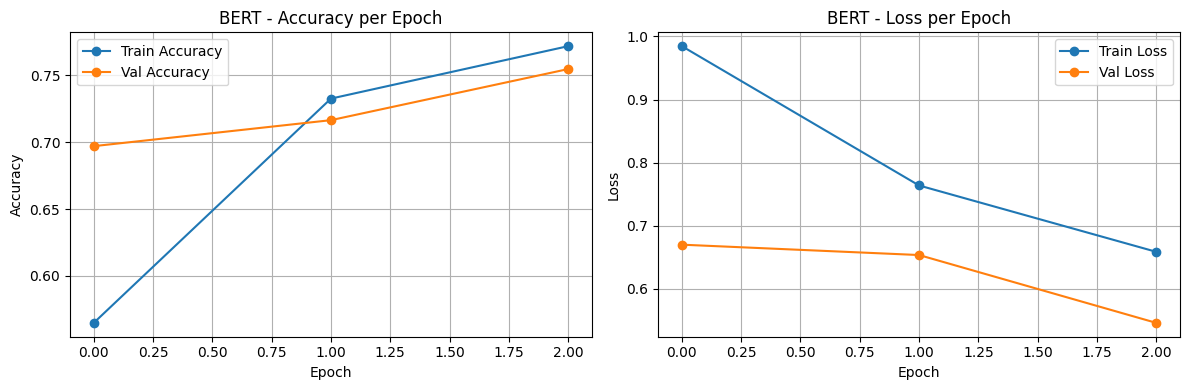

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
axes[0].plot(history.history["accuracy"],     label="Train Accuracy", marker="o")
axes[0].plot(history.history["val_accuracy"], label="Val Accuracy",   marker="o")
axes[0].set_title("BERT - Accuracy per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history.history["loss"],     label="Train Loss", marker="o")
axes[1].plot(history.history["val_loss"], label="Val Loss",   marker="o")
axes[1].set_title("BERT - Loss per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Step 10 - Model Summary Table

In [33]:
summary = pd.DataFrame({
    "Model"             : ["BERT (bert-base-uncased)"],
    "Test Accuracy"     : [round(test_acc, 4)],
    "Macro F1"          : [round(macro_f1, 4)],
    "Parameters"        : [model.count_params()],
    "Training Time (s)" : [round(bert_train_time, 1)]
})
summary

,Model,Test Accuracy,Macro F1,Parameters,Training Time (s)
0,BERT (bert-base-uncased),0.7547,0.5966,108507907,1404.0


## Step 11 - Predict Sentiment on New Buyer Reviews

Demonstrate the model on real example reviews to show how it analyses buyer feelings.


In [36]:
def predict_sentiment(review_texts, tokenizer, model, max_length=MAX_LENGTH):

    label_map = {
        0: "Negative (unhappy buyer)",
        1: "Neutral (mixed feelings)",
        2: "Positive (happy buyer)"
    }

    cleaned = [preprocess_text(t) for t in review_texts]

    tokens = tokenizer(
        cleaned,
        max_length=max_length,
        truncation=True,
        padding="max_length",
        return_tensors="tf",
        return_attention_mask=True,
        return_token_type_ids=True
    )

    preds = model.predict(
        {
            "token_ids": tokens["input_ids"],
            "padding_mask": tokens["attention_mask"],
            "segment_ids": tokens["token_type_ids"],
        },
        verbose=0,
    )

    labels = np.argmax(preds, axis=1)

    for i, (text, pred) in enumerate(zip(review_texts, labels)):
        conf = preds[i][pred]

        print("=" * 70)
        print("Review:")
        print(text)
        print()
        print("Prediction :", label_map[pred])
        print(f"Confidence : {conf:.2%}")

---
## Summary

| Step | What we did |
|------|-------------|
| 1 | Loaded and explored the **Womens Clothing Reviews** dataset |
| 2 | Derived **3-class sentiment labels** from star ratings |
| 3 | Cleaned and preprocessed review text |
| 4 | Split into **80% train / 20% test** (stratified) |
| 5 | Tokenized with **BertTokenizerFast** (bert-base-uncased) |
| 6 | Built a **BERT fine-tuning model** with a Dense classification head |
| 7 | Trained for up to 3 epochs with **EarlyStopping** |
| 8 | Evaluated with full **Classification Report** (precision, recall, F1) |
| 9 | Visualised training curves (accuracy and loss) |
| 10 | Demonstrated live predictions on new buyer reviews |

### What does this analysis tell us?
By reading a buyers written review, the model can automatically classify
**how the buyer feels about the product**:
- Businesses can use this to **monitor customer satisfaction at scale** without reading every review manually
- It helps identify **problematic products** (many negative reviews) quickly
- It can power dashboards that show **sentiment trends** over time

